# Algorytm Grahama

In [21]:
%run interface.ipynb
%run tests.ipynb
import numpy as np

### Algorytm bez wizualizacji

In [2]:
def orient(a, b, c):
    # Określa orientację punktów (a, b, c)
    result = a.x * b.y + b.x * c.y + a.y * c.x - c.x * b.y - b.x * a.y - a.x * c.y
    
    if result > 10e-12:
        return 1  # Przeciwnie do ruchu wskazówek zegara
    elif result < -10e-12:
        return -1 # Zgodnie z ruchem wskazówek zegara
    else:
        return 0  # Współliniowe

In [3]:
def find_min_point(points):
    """
    Wyznaczanie punktu o najmniejszej współrzędnej y. W przypadku kilku punktów o tej samej współrzędne y wybieramy tą z najmniejszą współrzędną x
    :param points: lista wszystkich punktów
    :return: punkt o najmniejszej współrzędnej y (w przypadku kilku punktów o tej samej współrzędnej y zwracamy ten o najmniejszej współrzędnej x)
    """
    n = len(points)
    min_point = points[0]

    for i in range(1, n):
        if points[i].y < min_point.y or (points[i].y == min_point.y and points[i].x < min_point.x):
            min_point = points[i]
    return min_point

In [4]:
def set_angle_and_distance(points, q):
    """
    Wyznaczanie kąta wyznaczanego przez punkty p i q względem osi x oraz obliczanie odległości między punktami p i q
    :param points: lista wszystkich punktów
    :param q: punkt startowy otoczki
    :return: lista krotek zawierająca kąt między punktami p i q względem osi x, odległość między punktami p i q, współrzędne punktu p
    """
    P = [(0, 0, q.x, q.y)]
    for p in points:
        if p == q: continue
        x_delta = p.x - q.x
        y_delta = p.y - q.y
        p_q_dist = (x_delta**2 + y_delta**2)**0.5
        angle = (int(np.arccos(x_delta/p_q_dist)*10**12)) / 10**12
        P.append((angle, p_q_dist, p.x, p.y))
    return P

In [5]:
def delete_colinear(P):
    """
    Usuwanie wszystkich punktów, które tworzą ten sam kąt (co oznacza, że leżą na jednej prostej i nie ma potrzeby rozpatrywać je wszystkie, 
    wystarczy tylko ten najdalej oddalony od punktu początkowego q)
    :param P: posortowana lista krotek zawierających kąt wyznaczony przez punkty p i q względem osi x, odległość między punktami p i q oraz 
              współrzędne punktu p
    :return: lista krotek zawierających współrzędne punktów po usunięciu wszystkich wspóliniowych punktów
    """
    A = [(P[0][2], P[0][3])]
    n = len(P)
    for i in range(2, n):
        if P[i][0] > P[i - 1][0]:
            A.append((P[i - 1][2], P[i - 1][3]))
    if n > 1: 
        A.append((P[n - 1][2], P[n - 1][3]))
    return A

In [6]:
def graham_algorithm(Q):
    '''
    Funkcja buduje otoczkę wypukłą dla podanego
    zbioru punktów Q algorymem Grahama
    :parm Q: zbiór punktów
    :return: tablica punktów w postaci krotek współrzędnych
    '''
    q = find_min_point(Q)
    A = set_angle_and_distance(Q, q)
    A.sort()
    T = delete_colinear(A)
    S = []
    n = len(T)
    PT = []
    for p in T:
        PT.append(Point(p[0], p[1]))
    for i in range(min(n, 3)):
        S.append(PT[i])
    for i in range(3, n):
        while len(S) > 2 and orient(S[-2], S[-1], PT[i]) <= 0:
            S.pop()
        S.append(PT[i])
    return S

### Testy poprawności

In [22]:
run_test(graham_algorithm)

Test 1:
	Czas: 0.0006s
	Wynik: POPRAWNY
Test 2:
	Czas: 0.001s
	Wynik: POPRAWNY
Test 3:
	Czas: 0.0012s
	Wynik: POPRAWNY
Test 4:
	Czas: 0.0024s
	Wynik: POPRAWNY
Test 5:
	Czas: 0.0021s
	Wynik: POPRAWNY
PODSUMOWANIE
Wynik: 5/5
Czas: 0.0073s


### Zadawanie zbioru punktów

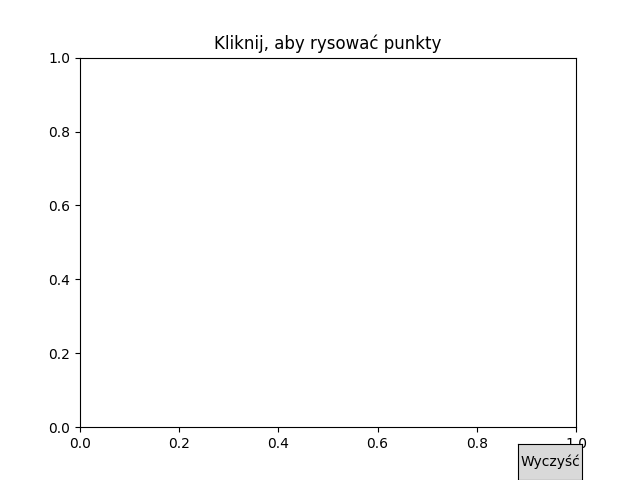

In [21]:
polygon = PolygonDrawer()

### Algorytm wraz z wizualizacją

In [22]:
def graham_algorithm_visual(Q):
    
    if not Q:
        return None 
    
    visualizer = ConvexHullVisualizer()
    visualizer.add_frame(Q, [], [], [], None)

    q = find_min_point(Q)
    A = set_angle_and_distance(Q, q)
    A.sort()
    T = delete_colinear(A)

    S = []
    n = len(T)
    PT = [Point(p[0], p[1]) for p in T]

    for i in range(min(n, 3)):
        S.append(PT[i])
        visualizer.add_frame(Q, [], [S], [], PT[i])

    for i in range(3, n):
        while len(S) > 2 and orient(S[-2], S[-1], PT[i]) <= 0:
            S.pop()
            visualizer.add_frame(Q, [], [S], [], PT[i])
        S.append(PT[i])
        visualizer.add_frame(Q, [], [S], [], PT[i])

    S.append(S[0])
    visualizer.add_frame(Q, [], [S], [], S[0])
    
    display(visualizer.create_animation())

In [23]:
graham_algorithm_visual(polygon.points)